# **Cell 1 – Structure Scanner + Paths Skeleton**

In [1]:
import os
import json
from pathlib import Path
from datetime import datetime
import pandas as pd
from IPython.display import display

# ============================================================
# CONFIG
# ============================================================
ROOT = Path("/kaggle/input")
GROUP_NAME = "glaucoma-fundus"

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.gif', '.webp'}
META_EXTS  = {'.csv', '.tsv', '.xlsx', '.xls', '.json', '.txt', '.xml'}

structure = {}
meta_files = []

def is_image(p: Path) -> bool:
    return p.suffix.lower() in IMAGE_EXTS

def walk(path: Path, current_dict: dict):
    print(f"Checking → {path}")
    
    try:
        entries = sorted(path.iterdir())
    except PermissionError:
        print(f"  ⚠️  Permission denied: {path}")
        return

    has_image = any(is_image(e) for e in entries if e.is_file())
    
    if has_image:
        current_dict["__contains_images__"] = True
        current_dict["__subdirs__"] = [e.name for e in entries if e.is_dir()]
        print(f"  → Contains images. Stopping deeper traversal.")
        return

    for entry in entries:
        if entry.is_dir():
            current_dict[entry.name] = {}
            walk(entry, current_dict[entry.name])
        elif entry.suffix.lower() in META_EXTS:
            meta_files.append(str(entry))
            current_dict.setdefault("__meta_files__", []).append(entry.name)
            print(f"  → Found metadata: {entry.name}")

# ============================================================
# RUN SCAN
# ============================================================
print(f"Scanning structure for group: {GROUP_NAME}\n")
walk(ROOT, structure)

# Save structure
structure_path = f"/kaggle/working/{GROUP_NAME}_structure.json"
with open(structure_path, "w") as f:
    json.dump(structure, f, indent=2)
print(f"\n✅ Structure JSON saved → {structure_path}")

# ============================================================
# PATHS DB SKELETON
# ============================================================
paths_db = {
    "group": GROUP_NAME,
    "created": datetime.now().isoformat(),
    "datasets": {
        "PAPILA": {
            "kaggle_slug": "orvile/papila-retinal-fundus-images",
            "root": "",
            "images_folder": "",
            "csv": "",
            "type": "folder_based / with clinical data",
            "classes": ["healthy", "glaucoma", "suspect"],
            "notes": "Both eyes of same patient + OD/cup segmentation"
        },
        "SMDG": {
            "kaggle_slug": "deathtrooper/multichannel-glaucoma-benchmark-dataset",
            "root": "",
            "images_folder": "",
            "csv": "",
            "type": "folder_based / standardized",
            "classes": ["0 (non-glaucoma)", "1 (glaucoma)", "-1 (suspect)"],
            "notes": "Largest public glaucoma fundus collection (19 sources)"
        }
    }
}

paths_path = f"/kaggle/working/{GROUP_NAME}_paths_db.json"
with open(paths_path, "w") as f:
    json.dump(paths_db, f, indent=2)
print(f"✅ Paths DB skeleton saved → {paths_path}")

# ============================================================
# SHOW METADATA
# ============================================================
print("\n===== METADATA / CSV FILES FOUND =====")
if meta_files:
    df_meta = pd.DataFrame({
        "Metadata File": meta_files,
        "Parent Folder": [str(Path(p).parent) for p in meta_files]
    })
    display(df_meta)
else:
    print("No CSV / metadata files found.")

print("\nDone. Paste the scan output (especially folder names + metadata table).")

Scanning structure for group: glaucoma-fundus

Checking → /kaggle/input
Checking → /kaggle/input/datasets
Checking → /kaggle/input/datasets/deathtrooper
Checking → /kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset
Checking → /kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/blood-vessel
Checking → /kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/blood-vessel/blood-vessel
  → Contains images. Stopping deeper traversal.
Checking → /kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/full-fundus
Checking → /kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/full-fundus/full-fundus
  → Contains images. Stopping deeper traversal.
  → Found metadata: metadata - standardized.csv
Checking → /kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/optic-cup
Checking → /kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/optic-cup

,Metadata File,Parent Folder
0,/kaggle/input/datasets/deathtrooper/multichann...,/kaggle/input/datasets/deathtrooper/multichann...
1,/kaggle/input/datasets/orvile/papila-retinal-f...,/kaggle/input/datasets/orvile/papila-retinal-f...
2,/kaggle/input/datasets/orvile/papila-retinal-f...,/kaggle/input/datasets/orvile/papila-retinal-f...
3,/kaggle/input/datasets/orvile/papila-retinal-f...,/kaggle/input/datasets/orvile/papila-retinal-f...
4,/kaggle/input/datasets/orvile/papila-retinal-f...,/kaggle/input/datasets/orvile/papila-retinal-f...
...,...,...
1981,/kaggle/input/datasets/orvile/papila-retinal-f...,/kaggle/input/datasets/orvile/papila-retinal-f...
1982,/kaggle/input/datasets/orvile/papila-retinal-f...,/kaggle/input/datasets/orvile/papila-retinal-f...
1983,/kaggle/input/datasets/orvile/papila-retinal-f...,/kaggle/input/datasets/orvile/papila-retinal-f...
1984,/kaggle/input/datasets/orvile/papila-retinal-f...,/kaggle/input/datasets/orvile/papila-retinal-f...



Done. Paste the scan output (especially folder names + metadata table).


# **Final Paths DB**

In [2]:
import json
from datetime import datetime

paths_db = {
    "group": "glaucoma-fundus",
    "created": datetime.now().isoformat(),
    "datasets": {
        "PAPILA": {
            "kaggle_slug": "orvile/papila-retinal-fundus-images",
            "root": "/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f",
            "images_folder": "/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/FundusImages",
            "clinical_od": "/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/ClinicalData/patient_data_od.xlsx",
            "clinical_os": "/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/ClinicalData/patient_data_os.xlsx",
            "type": "folder_based + clinical data",
            "classes": ["healthy", "glaucoma", "suspect"],
            "notes": "Both eyes of same patient + OD/cup segmentations"
        },
        "SMDG": {
            "kaggle_slug": "deathtrooper/multichannel-glaucoma-benchmark-dataset",
            "root": "/kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset",
            "images_folder": "/kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/full-fundus/full-fundus",
            "csv": "/kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/metadata - standardized.csv",
            "type": "folder_based + metadata csv",
            "classes": ["0 (non-glaucoma)", "1 (glaucoma)", "-1 (suspect)"],
            "notes": "Largest public glaucoma collection (19 sources combined)"
        }
    }
}

with open("/kaggle/working/glaucoma-fundus_paths_db.json", "w") as f:
    json.dump(paths_db, f, indent=2)

print("✅ paths_db saved")
print(json.dumps(paths_db, indent=2))

✅ paths_db saved
{
  "group": "glaucoma-fundus",
  "created": "2026-09-24T06:44:58.817301",
  "datasets": {
    "PAPILA": {
      "kaggle_slug": "orvile/papila-retinal-fundus-images",
      "root": "/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f",
      "images_folder": "/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/FundusImages",
      "clinical_od": "/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/ClinicalData/patient_data_od.xlsx",
      "clinical_os": "/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/ClinicalData/patient_data_os.xlsx",
      "type": "folder_based + clinical data",
      "classes": [
        "healthy",
        "glaucoma",
        "suspect"
      ],
      "notes": "Both eyes of same patient + OD/cu

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

def analyze_dataset(dataset_name: str, root_path: str, class_folders: list = None, 
                    csv_path: str = None, label_col: str = None, image_col: str = None,
                    max_samples_per_class: int = 3):
    """
    Universal analyzer for fundus datasets.
    """
    
    print("="*80)
    print(f"DATASET: {dataset_name}")
    print("="*80)
    
    root = Path(root_path)
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    
    data = []
    
    if csv_path is not None:
        df = pd.read_csv(csv_path)
        print(f"CSV loaded: {csv_path}  |  shape = {df.shape}")
        print("Columns:", df.columns.tolist())
        
        if label_col is None or image_col is None:
            print("⚠️  Please provide label_col and image_col")
            return
        
        for _, row in df.iterrows():
            img_name = str(row[image_col])
            label = str(row[label_col])
            possible = list(root.rglob(img_name))
            if not possible:
                possible = list(root.rglob(f"*{Path(img_name).stem}*"))
            if possible:
                data.append((label, possible[0]))
    else:
        if class_folders is None:
            class_folders = []
            for p in root.iterdir():
                if p.is_dir():
                    has_img = any(f.suffix.lower() in image_exts for f in p.rglob("*") if f.is_file())
                    if has_img:
                        class_folders.append(p.name)
        
        print(f"Class folders found: {class_folders}")
        
        for cls in class_folders:
            cls_path = root / cls
            if not cls_path.exists():
                matches = list(root.rglob(cls))
                if matches:
                    cls_path = matches[0]
                else:
                    continue
            
            for img_path in cls_path.rglob("*"):
                if img_path.suffix.lower() in image_exts:
                    data.append((cls, img_path))
    
    if len(data) == 0:
        print("❌ No images found. Check the path.")
        return
    
    # Summary table
    class_counts = Counter([d[0] for d in data])
    total_images = sum(class_counts.values())
    
    res_per_class = defaultdict(set)
    size_per_class = defaultdict(list)
    
    print("\nCollecting resolution & size info...")
    for cls, path in data:
        try:
            img = cv2.imread(str(path))
            if img is None:
                continue
            h, w = img.shape[:2]
            res_per_class[cls].add(f"{w}x{h}")
            size_mb = path.stat().st_size / (1024 * 1024)
            size_per_class[cls].append(size_mb)
        except:
            pass
    
    rows = []
    for cls in sorted(class_counts.keys()):
        count = class_counts[cls]
        pct = count / total_images * 100
        resolutions = ", ".join(sorted(res_per_class[cls])) if res_per_class[cls] else "N/A"
        avg_size = np.mean(size_per_class[cls]) if size_per_class[cls] else 0
        rows.append({
            "Class": cls,
            "Image Count": count,
            "Percentage": f"{pct:.1f}%",
            "Resolution(s)": resolutions,
            "Avg Size (MB)": f"{avg_size:.3f}"
        })
    
    all_sizes = [s for sizes in size_per_class.values() for s in sizes]
    rows.append({
        "Class": "TOTAL",
        "Image Count": total_images,
        "Percentage": "100%",
        "Resolution(s)": "-",
        "Avg Size (MB)": f"{np.mean(all_sizes):.3f}" if all_sizes else "0"
    })
    
    df_summary = pd.DataFrame(rows)
    print("\n----- SUMMARY TABLE -----")
    display(df_summary)
    
    # Sample images
    print("\n----- SAMPLE IMAGES PER CLASS -----")
    classes = sorted(class_counts.keys())
    samples = defaultdict(list)
    for cls, path in data:
        if len(samples[cls]) < max_samples_per_class:
            samples[cls].append(path)
    
    cols = min(max_samples_per_class, 3)
    rows_plot = len(classes)
    
    fig, axes = plt.subplots(rows_plot, cols, figsize=(4*cols, 3.5*rows_plot))
    if rows_plot == 1:
        axes = np.array([axes])
    if cols == 1:
        axes = axes.reshape(-1, 1)
    
    for i, cls in enumerate(classes):
        for j in range(cols):
            ax = axes[i, j]
            if j < len(samples[cls]):
                img = cv2.imread(str(samples[cls][j]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                ax.set_title(f"{cls}", fontsize=10)
            ax.axis("off")
    
    plt.suptitle(f"{dataset_name} – Sample Images", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    
    # Stats
    print("\n----- IMAGE STATISTICAL ANALYSIS -----")
    all_widths, all_heights, all_sizes_mb = [], [], []
    channels = []
    
    for cls, path in data[:min(500, len(data))]:
        try:
            img = cv2.imread(str(path))
            if img is None:
                continue
            h, w = img.shape[:2]
            all_widths.append(w)
            all_heights.append(h)
            all_sizes_mb.append(path.stat().st_size / (1024*1024))
            channels.append(img.shape[2] if len(img.shape) == 3 else 1)
        except:
            pass
    
    stats = {
        "Total Images Analyzed": len(all_widths),
        "Unique Resolutions": len(set(zip(all_widths, all_heights))),
        "Width  – min / mean / max": f"{min(all_widths)} / {np.mean(all_widths):.0f} / {max(all_widths)}",
        "Height – min / mean / max": f"{min(all_heights)} / {np.mean(all_heights):.0f} / {max(all_heights)}",
        "File Size (MB) – min / mean / max": f"{min(all_sizes_mb):.3f} / {np.mean(all_sizes_mb):.3f} / {max(all_sizes_mb):.3f}",
        "Channels (most common)": Counter(channels).most_common(1)[0][0] if channels else "N/A"
    }
    
    for k, v in stats.items():
        print(f"{k:35s} : {v}")
    
    print("\n" + "="*80 + "\n")

# **Analysis Cell**

DATASET: SMDG (full-fundus)
CSV loaded: /kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/metadata - standardized.csv  |  shape = (12449, 48)
Columns: ['names', 'types', 'type_expanded', 'isColor', 'original_name', 'patient_id', 'fundus', 'fundus_od_seg', 'fundus_oc_seg', 'bv_seg', 'artery_seg', 'vein_seg', 'oct', 'oct_oc_seg', 'oct_od_seg', 'sex', 'gender', 'age', 'eye', 'sbp', 'dbp', 'hr', 'iop', 'vcdr', 'Unnamed: 24', 'notchI_present', 'notchS_present', 'notchN_present', 'notchT_present', 'expert1_grade', 'expert2_grade', 'expert3_grade', 'expert4_grade', 'expert5_grade', 'cdr_avg', 'cdr_expert1', 'cdr_expert2', 'cdr_expert3', 'cdr_expert4', 'refractive_dioptre_1', 'refractive_dioptre_2', 'refractive_astigmatism', 'phakic_or_pseudophakic', 'iop_perkins', 'iop_pneumatic', 'pachymetry', 'axial_length', 'visual_field_mean_defect']


----- SUMMARY TABLE -----


,Class,Image Count,Percentage,Resolution(s),Avg Size (MB)
0,-1,133,1.1%,512x512,0.220
1,0,7549,60.6%,512x512,0.240
2,1,4767,38.3%,512x512,0.231
3,TOTAL,12449,100%,-,0.236



----- SAMPLE IMAGES PER CLASS -----


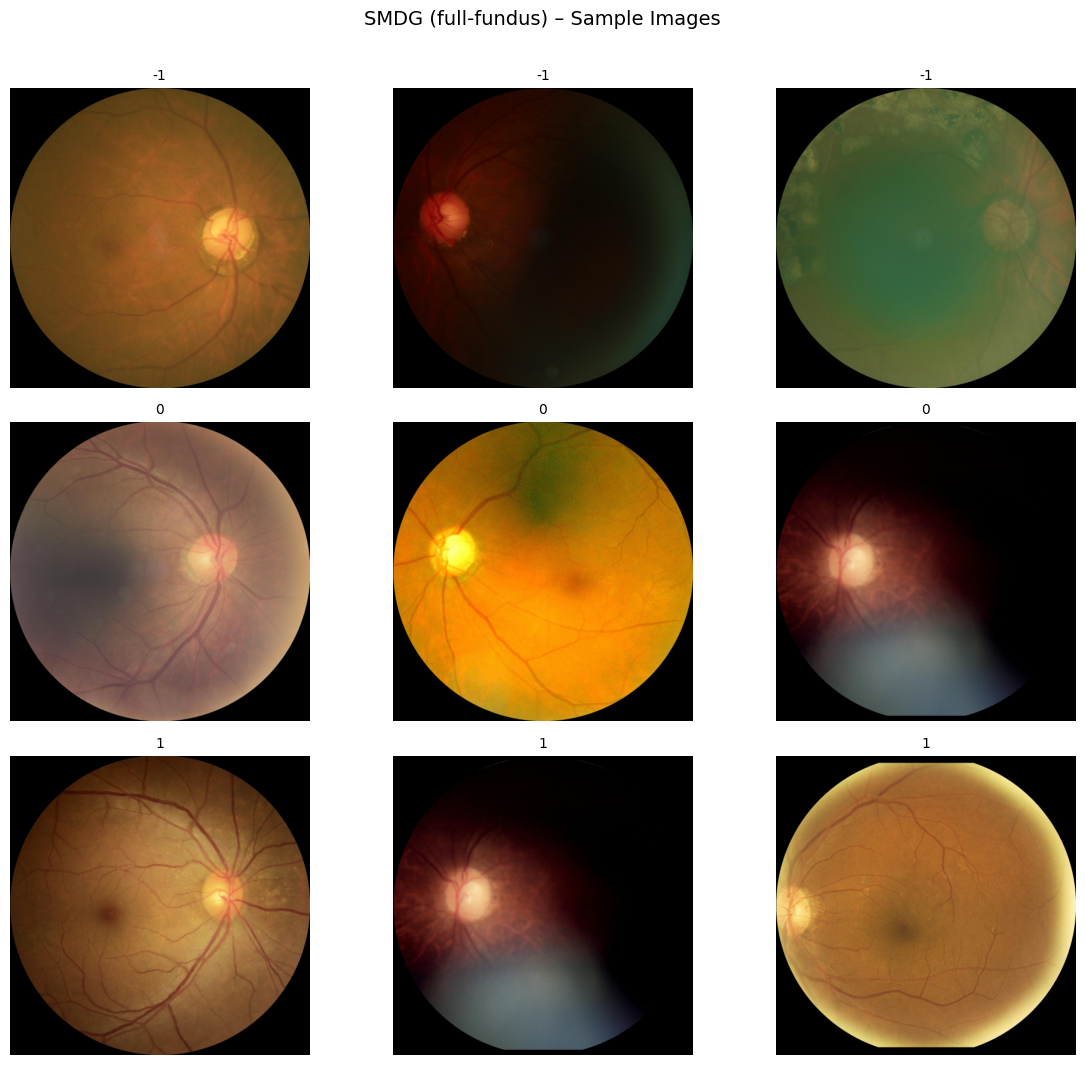


----- IMAGE STATISTICAL ANALYSIS -----
Total Images Analyzed               : 500
Unique Resolutions                  : 1
Width  – min / mean / max           : 512 / 512 / 512
Height – min / mean / max           : 512 / 512 / 512
File Size (MB) – min / mean / max   : 0.137 / 0.246 / 0.399
Channels (most common)              : 3




In [4]:
# SMDG - FIXED
analyze_dataset(
    dataset_name = "SMDG (full-fundus)",
    root_path    = "/kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/full-fundus/full-fundus",
    csv_path     = "/kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/metadata - standardized.csv",
    label_col    = "types",
    image_col    = "names"          # use 'names' instead of 'fundus'
)

Found 488 images


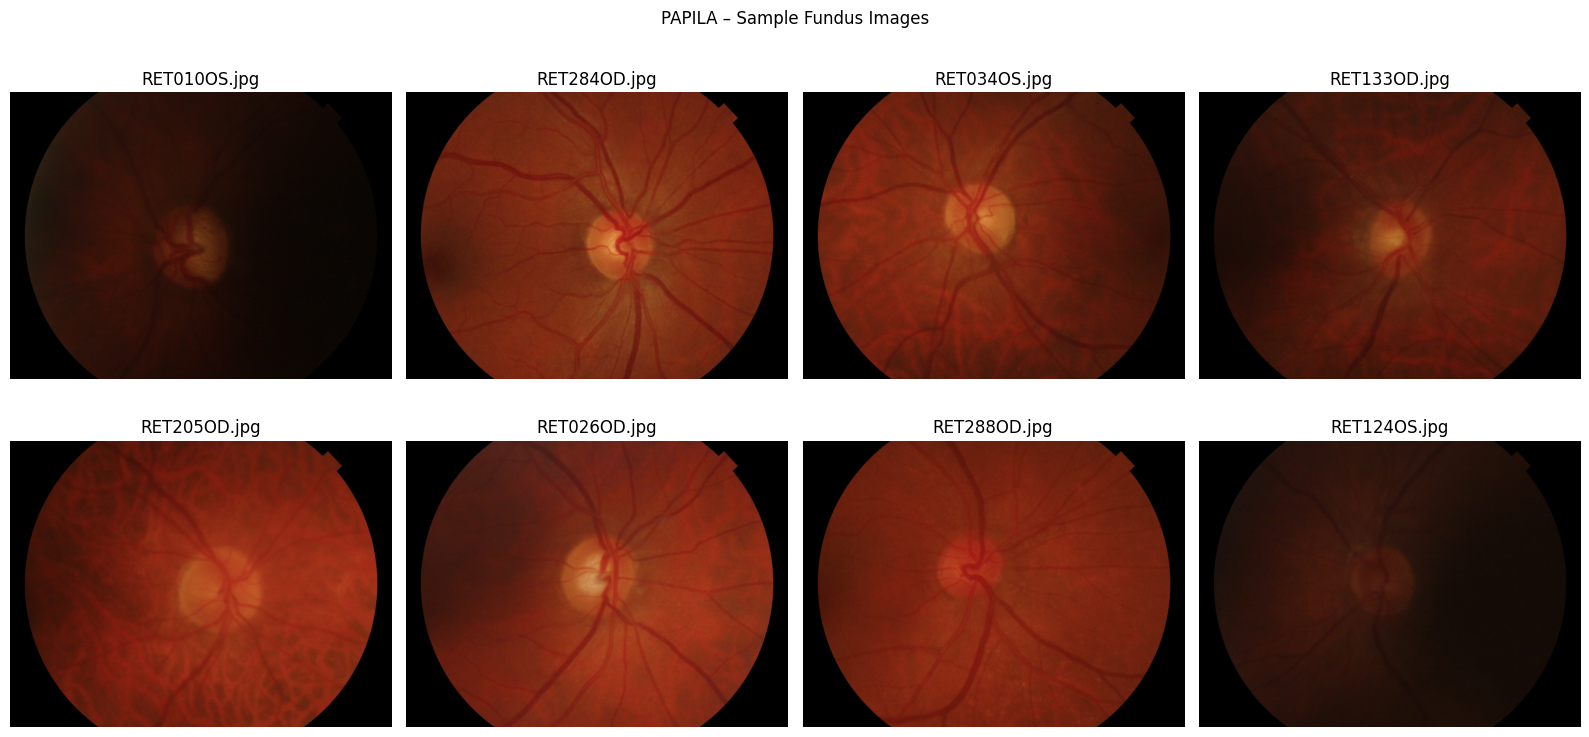

Total images : 488
Avg size     : 1.033 MB
Min / Max    : 0.799 / 1.142 MB


In [5]:
# PAPILA - FIXED (all images in one folder)
from pathlib import Path
import cv2
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

root = Path("/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/FundusImages")

image_files = list(root.glob("*.jpg")) + list(root.glob("*.png")) + list(root.glob("*.jpeg"))
print(f"Found {len(image_files)} images")

# Show a few samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, img_path in enumerate(image_files[:8]):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(img_path.name[:20])
    axes[i].axis("off")

plt.suptitle("PAPILA – Sample Fundus Images")
plt.tight_layout()
plt.show()

# Basic stats
sizes = [p.stat().st_size / (1024*1024) for p in image_files]
print(f"Total images : {len(image_files)}")
print(f"Avg size     : {np.mean(sizes):.3f} MB")
print(f"Min / Max    : {min(sizes):.3f} / {max(sizes):.3f} MB")

In [6]:
import json
import pandas as pd
from pathlib import Path
from datetime import datetime
from IPython.display import display

# ============================================================
# 1. PATHS DATABASE
# ============================================================
paths_db = {
    "group": "glaucoma-fundus",
    "created": datetime.now().isoformat(),
    "datasets": {
        "PAPILA": {
            "kaggle_slug": "orvile/papila-retinal-fundus-images",
            "root": "/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f",
            "images_folder": "/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/FundusImages",
            "clinical_od": "/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/ClinicalData/patient_data_od.xlsx",
            "clinical_os": "/kaggle/input/datasets/orvile/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/ClinicalData/patient_data_os.xlsx",
            "type": "folder_based + clinical data",
            "classes": ["healthy", "glaucoma", "suspect"],
            "notes": "Both eyes of same patient + OD/cup segmentations"
        },
        "SMDG": {
            "kaggle_slug": "deathtrooper/multichannel-glaucoma-benchmark-dataset",
            "root": "/kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset",
            "images_folder": "/kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/full-fundus/full-fundus",
            "csv": "/kaggle/input/datasets/deathtrooper/multichannel-glaucoma-benchmark-dataset/metadata - standardized.csv",
            "type": "folder_based + metadata csv",
            "classes": ["0 (non-glaucoma)", "1 (glaucoma)", "-1 (suspect)"],
            "notes": "Largest public glaucoma collection (19 sources combined)"
        }
    }
}

# ============================================================
# 2. SUMMARY LOGS DB
# (Fill with real numbers after you finish analyzing)
# ============================================================
summary_db = {
    "group": "glaucoma-fundus",
    "created": datetime.now().isoformat(),
    "results": {
        # Example – replace after analysis
        # "SMDG": {
        #     "total_images": 12449,
        #     "classes": {"0": 7499, "1": 4817, "-1": 133},
        #     "resolution": "512x512",
        #     "avg_size_mb": 0.15
        # },
        # "PAPILA": {
        #     "total_images": 488,
        #     "classes": {"healthy": 333, "glaucoma": 87, "suspect": 68},
        #     "resolution": "...",
        #     "avg_size_mb": 0.8
        # }
    }
}

# ============================================================
# 3. MASTER TABLE + SIZE + TOTALS
# ============================================================
def get_folder_size_mb(folder_path: str) -> float:
    total = 0
    path = Path(folder_path)
    if not path.exists():
        return 0.0
    for f in path.rglob("*"):
        if f.is_file():
            total += f.stat().st_size
    return total / (1024 * 1024)

master_rows = []

for name, info in paths_db["datasets"].items():
    images_folder = info.get("images_folder") or info.get("root")
    size_mb = get_folder_size_mb(images_folder)
    result = summary_db["results"].get(name, {})
    
    master_rows.append({
        "Dataset": name,
        "Kaggle_Slug": info["kaggle_slug"],
        "Type": info["type"],
        "Num_Classes": len(info["classes"]),
        "Total_Images": result.get("total_images", 0),
        "Resolution": result.get("resolution", ""),
        "Avg_Size_MB": result.get("avg_size_mb", 0),
        "Total_Size_MB": round(size_mb, 1),
        "Total_Size_GB": round(size_mb / 1024, 2),
        "Classes": " | ".join(info["classes"]),
        "Per_Class_Counts": " | ".join(
            f"{cls}:{cnt}" for cls, cnt in result.get("classes", {}).items()
        ),
        "Root_Path": info["root"],
        "Images_Folder": images_folder,
        "CSV_Path": info.get("csv", ""),
        "Notes": info.get("notes", "")
    })

df_master = pd.DataFrame(master_rows)

# Grand Totals
total_images = df_master["Total_Images"].sum()
total_size_mb = df_master["Total_Size_MB"].sum()
total_size_gb = total_size_mb / 1024

print("=" * 80)
print("MASTER SUMMARY TABLE – glaucoma-fundus")
print("=" * 80)
display(df_master[[
    "Dataset", "Num_Classes", "Total_Images", 
    "Total_Size_MB", "Total_Size_GB", "Resolution", "Avg_Size_MB"
]])

print("\n" + "=" * 80)
print("GRAND TOTALS")
print("=" * 80)
print(f"Total Datasets     : {len(df_master)}")
print(f"Total Images       : {total_images:,}")
print(f"Total Size         : {total_size_mb:,.1f} MB  ({total_size_gb:.2f} GB)")
print("=" * 80)

# Save
df_master.to_csv("/kaggle/working/glaucoma-fundus_master_table.csv", index=False)

with open("/kaggle/working/glaucoma-fundus_paths_db.json", "w") as f:
    json.dump(paths_db, f, indent=2)

with open("/kaggle/working/glaucoma-fundus_summary_db.json", "w") as f:
    json.dump(summary_db, f, indent=2)

print("\n✅ Files saved:")
print(" - glaucoma-fundus_paths_db.json")
print(" - glaucoma-fundus_summary_db.json")
print(" - glaucoma-fundus_master_table.csv")

MASTER SUMMARY TABLE – glaucoma-fundus


,Dataset,Num_Classes,Total_Images,Total_Size_MB,Total_Size_GB,Resolution,Avg_Size_MB
0,PAPILA,3,0,504.2,0.49,,0
1,SMDG,3,0,2936.7,2.87,,0



GRAND TOTALS
Total Datasets     : 2
Total Images       : 0
Total Size         : 3,440.9 MB  (3.36 GB)

✅ Files saved:
 - glaucoma-fundus_paths_db.json
 - glaucoma-fundus_summary_db.json
 - glaucoma-fundus_master_table.csv
